In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pillow_lab_rotation import lds
from importlib import reload
inv = np.linalg.inv
plt.style.use('../JS.mplstyle')

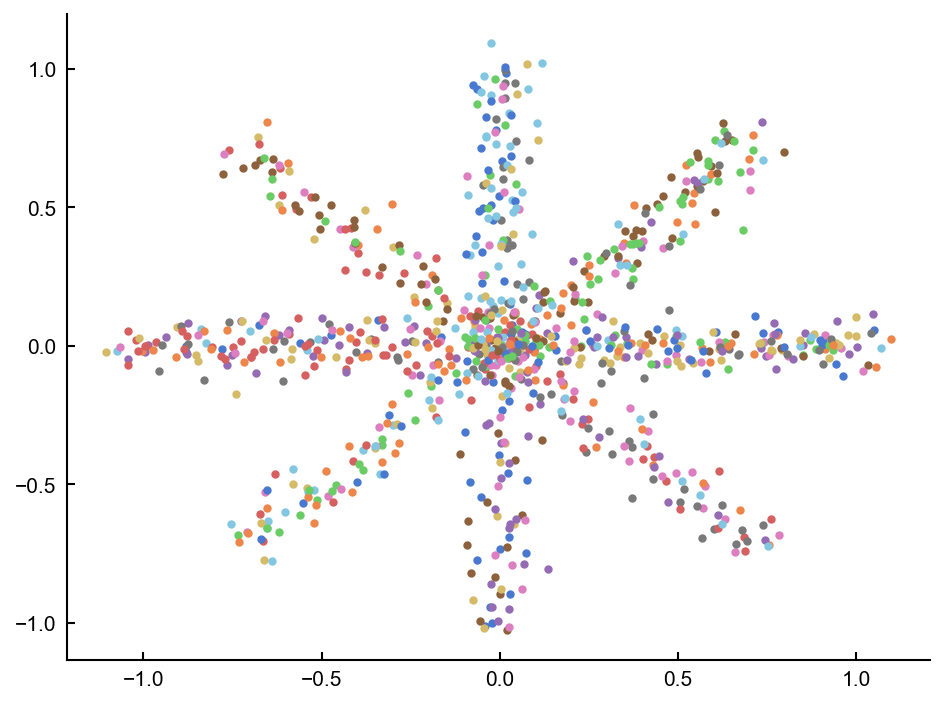

In [2]:
thetas = np.deg2rad(np.linspace(0, 360, 9))[:-1]
n_trials = 100
noise = 0.05
T = 10
r = np.linspace(0, 1, T)
X = np.zeros((n_trials, T, 2, 1))
for n in range(n_trials):
    theta = np.random.choice(thetas)
    # for i, theta in enumerate(thetas):
    x = r * np.cos(theta) + np.random.normal(0, noise, T)
    y = r * np.sin(theta) + np.random.normal(0, noise, T)
    X[n] = np.array([x, y]).T[..., None]
    plt.plot(x, y,  '.')

In [6]:
reload(lds)

<module 'pillow_lab_rotation.lds' from '/Users/jeremyschroeter/Desktop/the-ark/phd/rotations/pillow_lab_rotation/src/pillow_lab_rotation/lds.py'>

In [7]:
lds_model = lds.LinearDynamicalSystem(2, 2)

In [8]:
lds_model.fit(X)

In [9]:
from pillow_lab_rotation.plotting import plot_confidence_ellipse

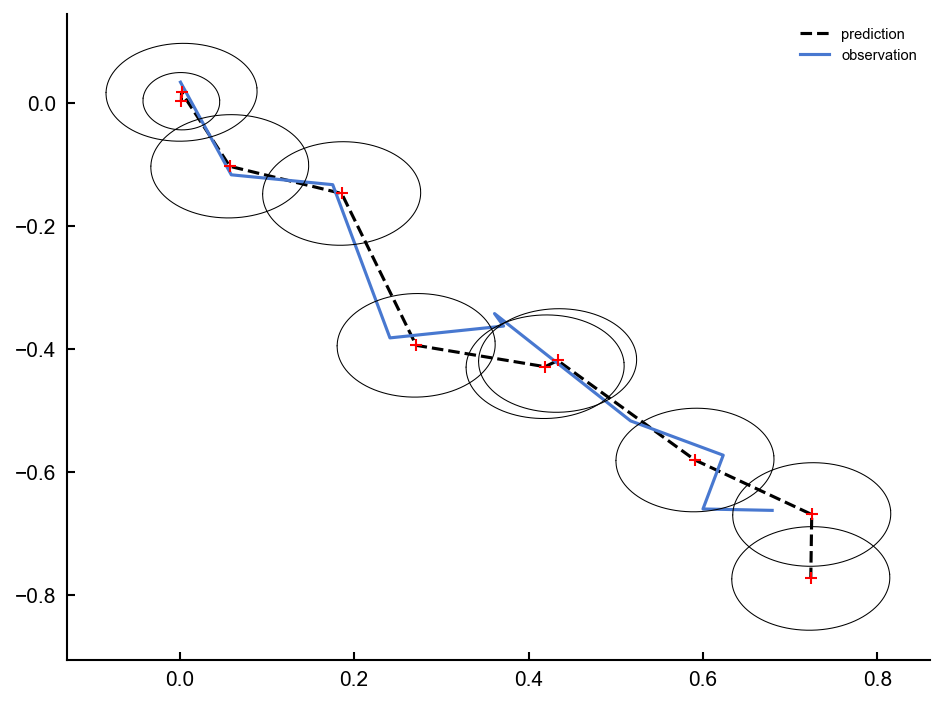

In [18]:
z_pred, pred_cvs, obs_mean, obs_cov, z_filt, post_covs, LL = lds_model.predict(X)
trial = 7

plt.plot(obs_mean[trial, :, 0, 0], obs_mean[trial, :, 1, 0], linestyle='--', label='prediction', c='k')
plt.plot(X[trial, :, 0, 0], X[trial, :, 1, 0], label='observation')
for t in range(T):
    plot_confidence_ellipse(obs_mean[trial, t, :, 0], obs_cov[trial, t])

plt.legend()